### Carga de datos

Esta celda importa la librería `pandas` y carga el archivo `housing.csv` en un DataFrame llamado `datos`.

In [1]:
import pandas as pd
datos = pd.read_csv("housing.csv")

### Visualización de las primeras filas

Esta celda muestra las primeras filas del DataFrame `datos` para obtener una vista previa de los datos.

In [2]:
datos.head

<bound method NDFrame.head of        longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
2        -122.24     37.85                52.0       1467.0           190.0   
3        -122.25     37.85                52.0       1274.0           235.0   
4        -122.25     37.85                52.0       1627.0           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.0   

       population  households  median_income  median_house_value  \
0           322.0       126.0         8.3252            452600.0   
1          2401.0      1138.0         8.3014            358500.0   
2           496.0       177.0         7.2574            352100.0   
3           558.0       219.0         5.6431            341300.0   
4           565.0       259.0         3.8462            342200.0   
...           ...         ...            ...                 ...   
20635       845.0       330.0         1.5603             78100.0   
20636       356.0       114.0         2.5568             77100.0   
20637      1007.0       433.0         1.7000             92300.0   
20638       741.0       349.0         1.8672             84700.0   
20639      1387.0       530.0         2.3886             89400.0   

      ocean_proximity  
0            NEAR BAY  
1            NEAR BAY  
2            NEAR BAY  
3            NEAR BAY  
4            NEAR BAY  
...               ...  
20635          INLAND  
20636          INLAND  
20637          INLAND  
20638          INLAND  
20639          INLAND  

[20640 rows x 10 columns]>

### Scatter plot de valor medio de vivienda por ubicación

Esta celda genera un diagrama de dispersión (`scatterplot`) de la latitud y longitud, coloreando los puntos según el `median_house_value` (valor medio de la vivienda) para visualizar la distribución geográfica de los precios de las casas.

<Axes: xlabel='latitude', ylabel='longitude'>

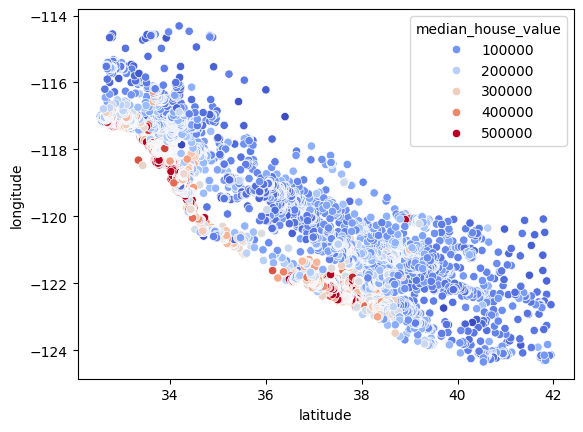

In [3]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="median_house_value", palette="coolwarm")

### Scatter plot de valor medio de vivienda y tamaño por ingreso medio

Similar a la anterior, esta celda crea otro diagrama de dispersión donde el color representa el `median_house_value` y el tamaño de los puntos (`size`) se ajusta según el `median_income` (ingreso medio). Esto permite observar la relación entre ubicación, valor de la vivienda e ingreso.

TypeError: cannot convert the series to <class 'float'>

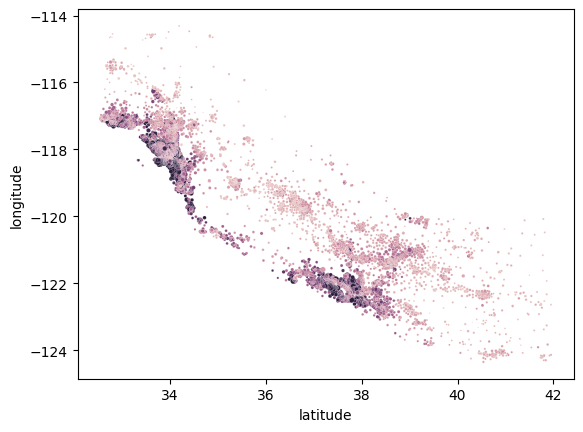

In [14]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="median_house_value", s=datos["median_income"])

### Selección de características para el clustering

Esta celda selecciona las columnas `latitude`, `longitude` y `median_income` del DataFrame `datos` y las almacena en un nuevo DataFrame `X`. Estas serán las características utilizadas para el algoritmo de clustering.

In [16]:
datos.loc[:, ["latitude", "longitude", "median_income"]]

,latitude,longitude,median_income
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462
...,...,...,...
20635,39.48,-121.09,1.5603
20636,39.49,-121.21,2.5568
20637,39.43,-121.22,1.7000
20638,39.43,-121.32,1.8672


### Aplicación del algoritmo K-Means

Esta celda importa `KMeans` de `sklearn.cluster`, inicializa el modelo con 3 clústeres y luego ajusta el modelo a los datos en `X` y predice las etiquetas de clúster para cada punto de datos. Las predicciones se almacenan en la variable `predicciones`.

In [20]:
from sklearn.cluster import KMeans

X = datos.loc[:, ["latitude", "longitude", "median_income"]]
modelo = KMeans(n_clusters=3)
predicciones = modelo.fit_predict(X)

### Verificación de la forma de las predicciones

Esta celda muestra la forma (dimensiones) del array `predicciones`, confirmando que tiene la misma cantidad de elementos que filas en `X`.

In [21]:
predicciones.shape

(20640,)

### Asignación de las predicciones al DataFrame

Esta celda añade una nueva columna llamada `segmento_economico` al DataFrame `X`, asignándole las etiquetas de clúster generadas por el modelo K-Means.

In [22]:
X["segmento_economico"] = predicciones

### Visualización del DataFrame con los segmentos

Esta celda muestra el DataFrame `X` actualizado, incluyendo la nueva columna `segmento_economico` con las asignaciones de clúster para cada fila.

In [24]:
X

,latitude,longitude,median_income,segmento_economico
0,37.88,-122.23,8.3252,0
1,37.86,-122.22,8.3014,0
2,37.85,-122.24,7.2574,0
3,37.85,-122.25,5.6431,0
4,37.85,-122.25,3.8462,0
...,...,...,...,...
20635,39.48,-121.09,1.5603,0
20636,39.49,-121.21,2.5568,0
20637,39.43,-121.22,1.7000,0
20638,39.43,-121.32,1.8672,0


### Conteo de elementos por segmento

Esta celda utiliza `value_counts()` para mostrar el número de puntos de datos que pertenecen a cada uno de los segmentos económicos (clústeres).

In [25]:
X["segmento_economico"].value_counts()

,count
segmento_economico,
1,9779
0,8439
2,2422


### Visualización de los segmentos económicos

Esta celda genera un diagrama de dispersión de `latitude` y `longitude`, coloreando los puntos según el `segmento_economico` para visualizar geográficamente los clústeres identificados.

<Axes: xlabel='latitude', ylabel='longitude'>

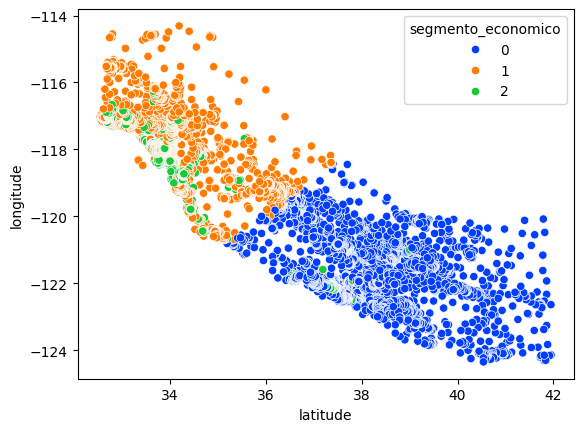

In [26]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=X, hue="segmento_economico", palette="bright")

### Conteo de los segmentos económicos

Esta celda crea un gráfico de barras (`countplot`) para visualizar la distribución del número de instancias en cada `segmento_economico`.

<Axes: xlabel='segmento_economico', ylabel='count'>

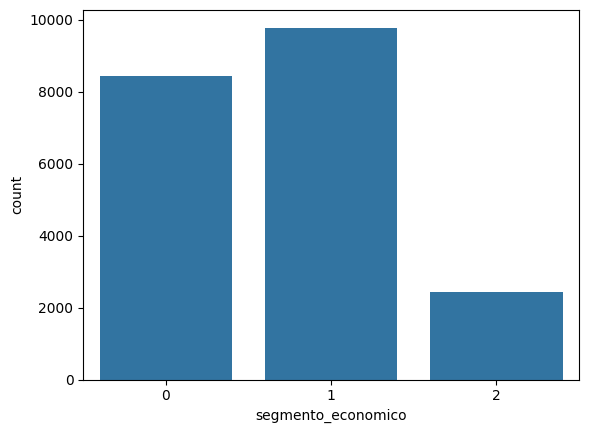

In [27]:
sb.countplot(x="segmento_economico", data=X)

### Cálculo del ingreso medio por segmento

Esta celda agrupa el DataFrame `X` por `segmento_economico` y calcula el `median_income` promedio para cada clúster. Esto ayuda a caracterizar cada segmento en términos de ingreso medio.

In [28]:
X.groupby(["segmento_economico"])["median_income"].mean()

,median_income
segmento_economico,
0,3.665502
1,3.211503
2,7.246981


# "Joven haga su trabajo por favor"

###### 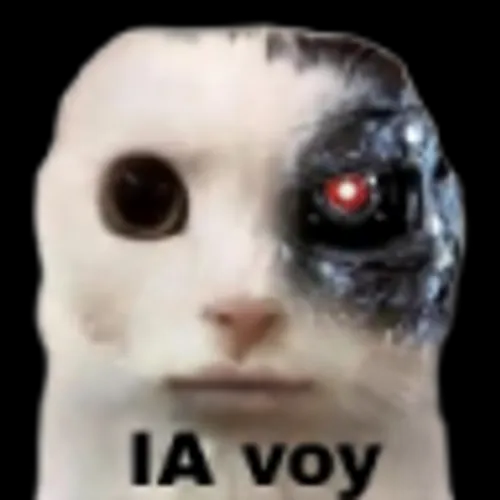